# Import Libraries 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset 

In [3]:
df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("df.dtypes: ", df.dtypes)
df.isnull().sum()
print(df['Use_Case'].value_counts())


df_clean = df[df['Uses_AI'] == 'Yes'].copy()
X = df_clean[['Year', 'Revenue_USD', 'Industry', 'Country', 'AI_Maturity_Score']]
X = pd.get_dummies(X)
y = df_clean['Use_Case']

df:        Year             Company    Industry Country Company_Type Employee_Size  \
0     2020              Amazon  E-commerce     USA         Real    Enterprise   
1     2021              Amazon  E-commerce     USA         Real    Enterprise   
2     2022              Amazon  E-commerce     USA         Real    Enterprise   
3     2023              Amazon  E-commerce     USA         Real    Enterprise   
4     2024              Amazon  E-commerce     USA         Real    Enterprise   
...    ...                 ...         ...     ...          ...           ...   
5995  2021  SyntheticCorp_0980     Telecom  Brazil    Synthetic    Enterprise   
5996  2022  SyntheticCorp_0980     Finance   India    Synthetic           SME   
5997  2023  SyntheticCorp_0980  Technology  Canada    Synthetic    Enterprise   
5998  2024  SyntheticCorp_0980   Logistics     UAE    Synthetic    Enterprise   
5999  2025  SyntheticCorp_0980  Healthcare   Japan    Synthetic           SME   

       Revenue_USD Use

# Numpy Operations 

In [4]:
# Revenue statistics by AI usage
revenue_ai = df[df['Uses_AI'] == 'Yes']['Revenue_USD'].values
revenue_no_ai = df[df['Uses_AI'] == 'No']['Revenue_USD'].values

print(f"Revenue (AI): Mean={np.mean(revenue_ai):.2e}, Std={np.std(revenue_ai):.2e}")
print(f"Revenue (No AI): Mean={np.mean(revenue_no_ai):.2e}, Std={np.std(revenue_no_ai):.2e}")

# Percentiles
percentiles = np.percentile(revenue_ai, [25, 50, 75])
print(f"25th, 50th, 75th percentile: {percentiles}")

Revenue (AI): Mean=1.62e+10, Std=4.72e+10
Revenue (No AI): Mean=1.20e+10, Std=2.64e+10
25th, 50th, 75th percentile: [2.17394227e+07 4.21911906e+07 2.13705761e+10]


# Seaborn Graphs

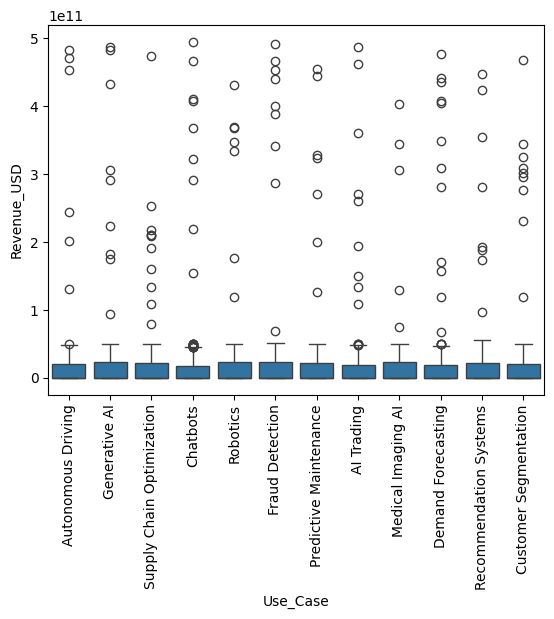

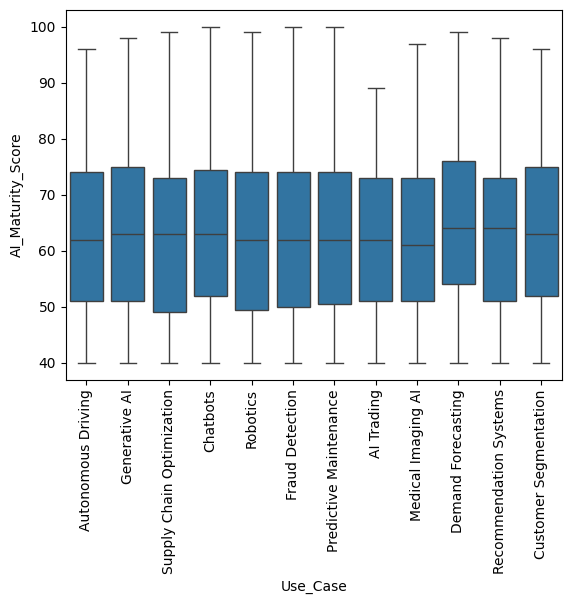

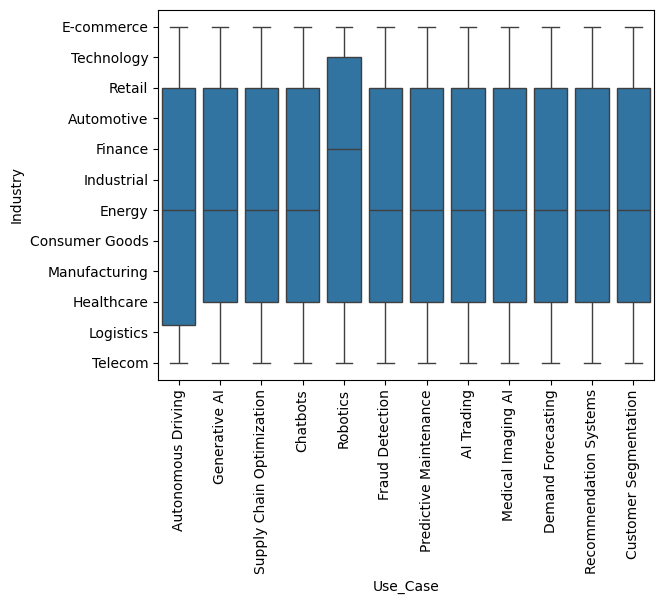

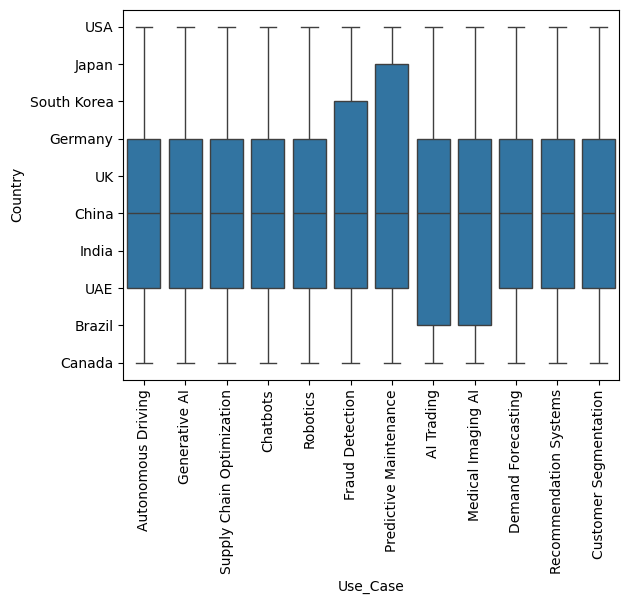

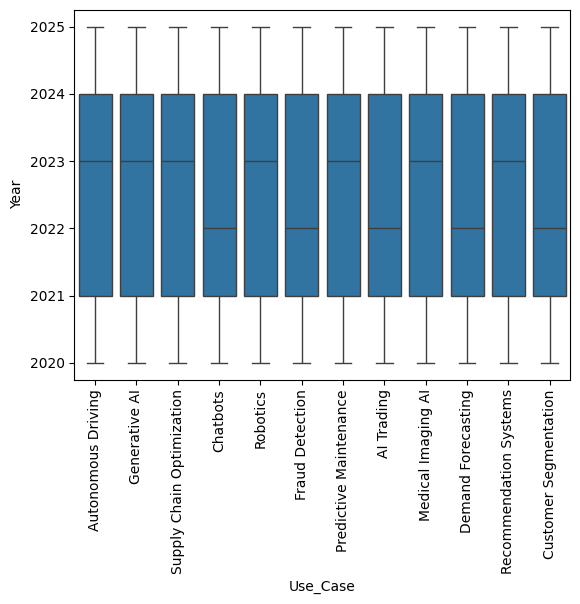

In [13]:
sns.boxplot(x='Use_Case', y='Revenue_USD', data=df)
plt.xticks(rotation=90)
plt.show()

sns.boxplot(x='Use_Case', y='AI_Maturity_Score', data=df)
plt.xticks(rotation=90)
plt.show()

sns.boxplot(x='Use_Case', y='Industry', data=df)
plt.xticks(rotation=90)
plt.show()

sns.boxplot(x='Use_Case', y='Country', data=df)
plt.xticks(rotation=90)
plt.show()

sns.boxplot(x='Use_Case', y='Year', data=df)
plt.xticks(rotation=90)
plt.show()

# Train Test Split Function

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=42,stratify=y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



from sklearn.linear_model import LogisticRegression


logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

log_reg_preds = logistic_regression.predict(X_test)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
print("KNN:\n", classification_report(y_test, knn_preds))


from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression:\n", classification_report(y_test, log_reg_preds))
print(confusion_matrix(y_test, log_reg_preds))

print("KNeighbor Classifier:\n", classification_report(y_test, log_reg_preds))
print(confusion_matrix(y_test, log_reg_preds))

from sklearn.metrics import roc_auc_score

# Logistic Regression
lr_proba = log_reg_preds.predict(X_test)[:,1]
print("LR AUC Score:", roc_auc_score(y_test, lr_proba))

# KNN
knn_proba = knn_preds.predict(X_test)[:,1]
print("KNN AUC Score:", roc_auc_score(y_test, knn_proba))



KNN:
                            precision    recall  f1-score   support

               AI Trading       0.08      0.22      0.12        82
       Autonomous Driving       0.07      0.13      0.09        75
                 Chatbots       0.07      0.09      0.08        86
    Customer Segmentation       0.05      0.06      0.06        83
       Demand Forecasting       0.12      0.09      0.10        80
          Fraud Detection       0.06      0.05      0.06        76
            Generative AI       0.10      0.06      0.08        82
       Medical Imaging AI       0.11      0.06      0.08        77
   Predictive Maintenance       0.10      0.06      0.08        81
   Recommendation Systems       0.15      0.10      0.12        81
                 Robotics       0.04      0.02      0.03        81
Supply Chain Optimization       0.03      0.01      0.02        86

                 accuracy                           0.08       970
                macro avg       0.08      0.08      0.

# Findings

In [ ]:

# Use_Case is randomly assigned and has no real relationship
# with other features in the dataset.

# Logistic Regression and KNN achieved only ~7% accuracy,
# which is close to random guessing for 12 classes.

# The dataset is not suitable for Use_Case classification.

# The main meaningful relationship is between AI_ROI and
# AI_Maturity_Score, making it more suitable for regression tasks.

